In [1]:
# ==========================================
# Standard Solution: Matrix–Vector Operations
# ==============================

import torch

# ----- Given -----
A = torch.tensor([[2., -1., 0.],
                  [1.,  3., 2.],
                  [0., -2., 1.]])
x = torch.tensor([[1.],
                  [2.],
                  [3.]])

# ----- 1) Compute y = A x -----
y = A @ x
print("A =\n", A)
print("x =\n", x)
print("y = A @ x =\n", y)
print("y shape:", y.shape)

# ----- 2) Compute z = A^T y -----
z = A.T @ y
print("\nA^T =\n", A.T)
print("z = A^T @ y =\n", z)

frobenius_norm = torch.linalg.matrix_norm(A, ord='fro')
x_norm = torch.linalg.vector_norm(x, ord=2)
dot_xy = torch.dot(x.squeeze(), y.squeeze())  # x^T·y

print("\nFrobenius norm of A:", frobenius_norm.item())
print("2-D norm of x:", x_norm.item())
print("Dot product x^T y:", dot_xy.item())


A =
 tensor([[ 2., -1.,  0.],
        [ 1.,  3.,  2.],
        [ 0., -2.,  1.]])
x =
 tensor([[1.],
        [2.],
        [3.]])
y = A @ x =
 tensor([[ 0.],
        [13.],
        [-1.]])
y shape: torch.Size([3, 1])

A^T =
 tensor([[ 2.,  1.,  0.],
        [-1.,  3., -2.],
        [ 0.,  2.,  1.]])
z = A^T @ y =
 tensor([[13.],
        [41.],
        [25.]])

Frobenius norm of A: 4.898979663848877
2-D norm of x: 3.7416574954986572
Dot product x^T y: 23.0


MSE (random weights): 0.867026
Epoch  200 | 误差 (Loss): 0.000038
Epoch  400 | 误差 (Loss): 0.000058
Epoch  600 | 误差 (Loss): 0.000581
Epoch  800 | 误差 (Loss): 0.000526
Epoch 1000 | 误差 (Loss): 0.000032
Epoch 1200 | 误差 (Loss): 0.000030
Epoch 1400 | 误差 (Loss): 0.000041
Epoch 1600 | 误差 (Loss): 0.000024
Epoch 1800 | 误差 (Loss): 0.000202
Epoch 2000 | 误差 (Loss): 0.000018

最终 MSE (trained weights): 0.000019


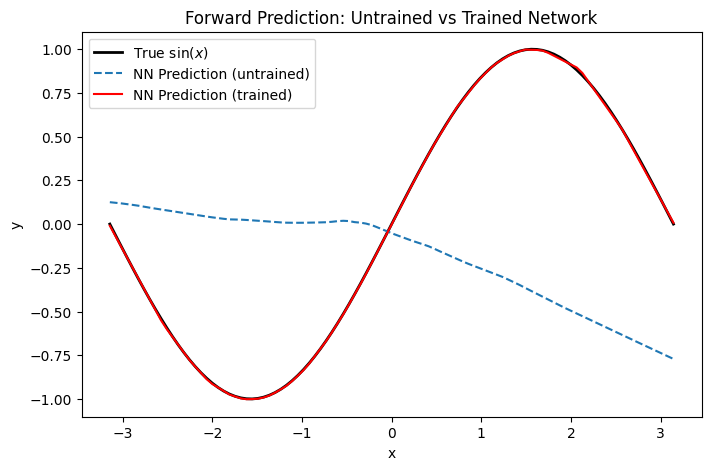

In [2]:
# %%
# =============================================
# Standard Solution: PyTorch Feedforward Network
# =============================================

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Data: y = sin(x)
torch.manual_seed(42)
x = torch.linspace(-torch.pi, torch.pi, 100).unsqueeze(1)
y = torch.sin(x)

# 2. Define model: 1 -> 32 -> 32 -> 1
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.LeakyReLU(0.01),
    nn.Linear(32, 32),
    nn.LeakyReLU(0.01),
    nn.Linear(32, 1)
)

# 3. Forward-only prediction (no training)
model.eval()
with torch.no_grad():
    y_pred_untrained = model(x)

# 4. Compute MSE loss (untrained)
mse_untrained = torch.mean((y_pred_untrained - y) ** 2)
print(f"MSE (random weights): {mse_untrained.item():.6f}")

# ================= 新增代码开始 =================
# 4.5 训练模型
model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# 跑 2000 个 Epoch
for epoch in range(2000):
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

    # === 最小改动：每 200 次打印一次拟合误差 (Loss) ===
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch + 1:4d} | 误差 (Loss): {loss.item():.6f}")

# 训练完成后，再做一次前向传播，获取训练后的结果
model.eval()
with torch.no_grad():
    y_pred_trained = model(x)
    
print(f"\n最终 MSE (trained weights): {criterion(y_pred_trained, y).item():.6f}")
# ================= 新增代码结束 =================

# 5. Visualization
plt.figure(figsize=(8,5))
plt.plot(x.numpy(), y.numpy(), label='True $\\sin(x)$', linewidth=2, color='black')
plt.plot(x.numpy(), y_pred_untrained.numpy(), label='NN Prediction (untrained)', linestyle='--')
plt.plot(x.numpy(), y_pred_trained.numpy(), label='NN Prediction (trained)', color='red')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Forward Prediction: Untrained vs Trained Network')
plt.show()


--- Part 3: CNN Convolution Truth & Learning ---

>>> 开始训练：让随机卷积层学会 '边缘检测' <<<
目标真实系数 (Sobel 5x5):
[[-0.0208 -0.0833 -0.125  -0.0833 -0.0208]
 [-0.0417 -0.1667 -0.25   -0.1667 -0.0417]
 [ 0.      0.      0.      0.      0.    ]
 [ 0.0417  0.1667  0.25    0.1667  0.0417]
 [ 0.0208  0.0833  0.125   0.0833  0.0208]]

目标误差设定为: 2e-06
Epoch  200 | 当前误差: 0.000307080
当前 5x5 核中心系数: 0.0525
Epoch  400 | 当前误差: 0.000089801
当前 5x5 核中心系数: 0.0075
Epoch  600 | 当前误差: 0.000032900
当前 5x5 核中心系数: -0.0146
Epoch  800 | 当前误差: 0.000015109
当前 5x5 核中心系数: -0.0257
Epoch 1000 | 当前误差: 0.000008434
当前 5x5 核中心系数: -0.0298
Epoch 1200 | 当前误差: 0.000005269
当前 5x5 核中心系数: -0.0300
Epoch 1400 | 当前误差: 0.000003452
当前 5x5 核中心系数: -0.0282
Epoch 1600 | 当前误差: 0.000002755
当前 5x5 核中心系数: -0.0257

✨ 达标！在第 1754 次迭代时误差降至 0.000001997
最终学到的卷积核系数:
[[-0.0231 -0.072  -0.1506 -0.091  -0.0023]
 [-0.0466 -0.1723 -0.2081 -0.1476 -0.0819]
 [ 0.0116 -0.0077 -0.0236 -0.0109  0.0345]
 [ 0.0383  0.1637  0.2681  0.1471  0.0354]
 [ 0.0193  0.0909  0.1096  

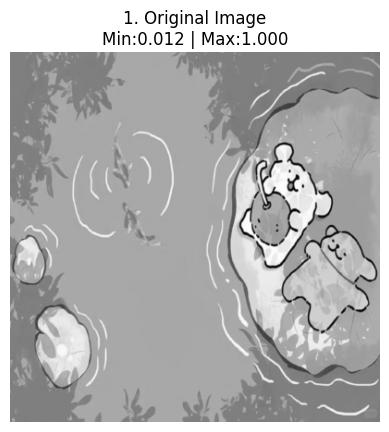

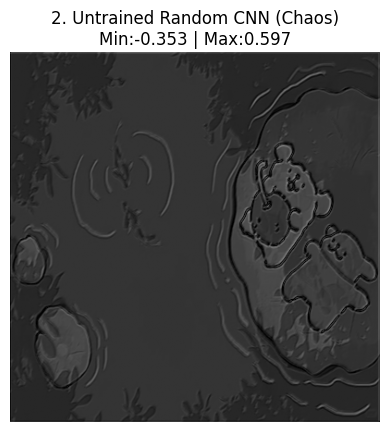

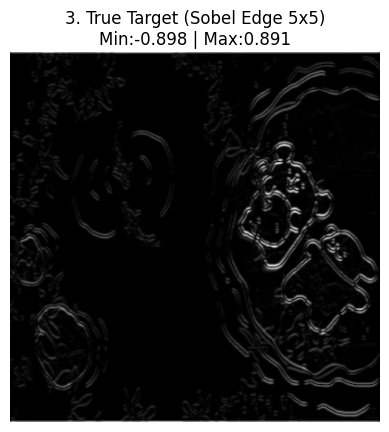

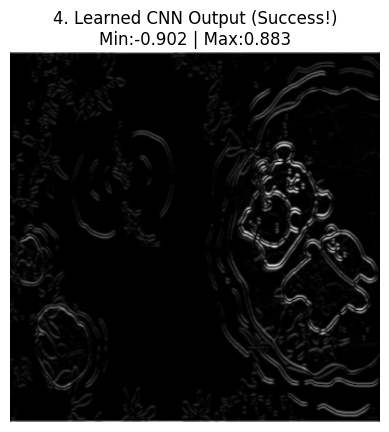

In [5]:
# ============================================================
# Part 3: CNN Dimensions, Padding Artifacts & Filter Learning
# ============================================================
print("\n--- Part 3: CNN Convolution Truth & Learning ---")
import os
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import numpy as np 
import matplotlib.pyplot as plt # 修复：补上 plt 导入

if os.path.exists("desktop.png"):
    img = Image.open("desktop.png").convert("L")
    transform = T.Compose([T.Resize((400, 400)), T.ToTensor()])
    x_img = transform(img).unsqueeze(0)
else:
    print("[Warning] desktop.png not found. Generating synthetic test image.")
    synth_img = torch.zeros((1, 1, 400, 400))
    synth_img[:, :, 100:300, 100:300] = 1.0  
    x_img = synth_img

# 1. 定义真实的物理边缘检测核 (作为我们要网络去学习的“标准答案”)
sobel_y_5x5 = torch.tensor([
    [-0.0208, -0.0833, -0.1250, -0.0833, -0.0208],
    [-0.0417, -0.1667, -0.2500, -0.1667, -0.0417],
    [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
    [ 0.0417,  0.1667,  0.2500,  0.1667,  0.0417],
    [ 0.0208,  0.0833,  0.1250,  0.0833,  0.0208]
])
# 修复：必须增加到 4 维 (Out_C=1, In_C=1, H=5, W=5)
sobel_y = sobel_y_5x5.unsqueeze(0).unsqueeze(0)

# 修复：标准答案的卷积层也必须是 5x5, padding=2
conv2 = nn.Conv2d(1, 1, kernel_size=5, stride=1, padding=2, bias=False)
with torch.no_grad():
    conv2.weight.copy_(sobel_y) # 使用 4 维的 sobel_y
    y2_target = conv2(x_img) # 这是标准答案图像

# ================= 新增训练代码开始 =================
print("\n>>> 开始训练：让随机卷积层学会 '边缘检测' <<<")
print(f"目标真实系数 (Sobel 5x5):\n{np.round(sobel_y[0,0].numpy(), 4)}\n")

# 定义一个完全随机的、准备学习的卷积层
learnable_conv = nn.Conv2d(1, 1, kernel_size=5, stride=1, padding=2, bias=False)

# 记录一下它未经训练时的糟糕表现
with torch.no_grad():
    y_untrained_cnn = learnable_conv(x_img)

optimizer_cnn = torch.optim.AdamW(learnable_conv.parameters(), lr=0.05) 
criterion_cnn = nn.MSELoss()

learnable_conv.train()
target_loss = 0.000002
max_epochs = 10000
epoch = 0

print(f"目标误差设定为: {target_loss}")

while True:
    epoch += 1
    optimizer_cnn.zero_grad()
    outputs = learnable_conv(x_img)
    loss = criterion_cnn(outputs, y2_target)
    loss.backward()
    optimizer_cnn.step()

    # 每 200 次打印一次状态
    if epoch % 200 == 0:
        current_weights = learnable_conv.weight.data[0, 0].cpu().numpy()
        print(f"Epoch {epoch:4d} | 当前误差: {loss.item():.9f}")
        print(f"当前 5x5 核中心系数: {current_weights[2, 2]:.4f}") # 仅打印中心点示范

    # 核心逻辑：达到精度要求，跳出循环
    if loss.item() < target_loss:
        print(f"\n✨ 达标！在第 {epoch} 次迭代时误差降至 {loss.item():.9f}")
        break
    
    # 达到安全上限，跳出循环
    if epoch >= max_epochs:
        print(f"\n停止：已达到最大迭代次数 {max_epochs}，当前误差为 {loss.item():.9f}")
        break

# 训练完成后，展示最终学到的 5x5 矩阵
final_weights = learnable_conv.weight.data[0, 0].cpu().numpy()
print(f"最终学到的卷积核系数:\n{np.round(final_weights, 4)}")
# 训练完成后，获取最终结果
learnable_conv.eval()
with torch.no_grad():
    y_learned_cnn = learnable_conv(x_img)
# ================= 新增训练代码结束 =================

def show_true_gray(tensor, title):
    min_val = tensor.min().item()
    max_val = tensor.max().item()
    img_array = torch.abs(tensor[0, 0]).detach().cpu().numpy()
    plt.imshow(img_array, cmap="gray", vmin=0, vmax=1) 
    plt.title(f"{title}\nMin:{min_val:.3f} | Max:{max_val:.3f}")
    plt.axis("off")
    plt.show()

# 依次展示：原图 -> 未训练的乱码 -> 真正的边缘检测 -> 机器学出来的边缘检测
show_true_gray(x_img, "1. Original Image")
show_true_gray(y_untrained_cnn, "2. Untrained Random CNN (Chaos)")
show_true_gray(y2_target, "3. True Target (Sobel Edge 5x5)")
show_true_gray(y_learned_cnn, "4. Learned CNN Output (Success!)")